# ECE 6357 - Final Project - Aigerim Keutayeva 

## Manual implementation of DES, 3DES, and AES-128

- This code is written for educational purposes for Intro to Cybersecurity project.
- It compares encryption and decryption time for DES, 3DES, and AES.

In [1]:
import time
import os
import csv

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Helper functions for DES

In [2]:
# Hexadecimal to binary conversion
def hex2bin(s):
    mp = {'0': "0000",
          '1': "0001",
          '2': "0010",
          '3': "0011",
          '4': "0100",
          '5': "0101",
          '6': "0110",
          '7': "0111",
          '8': "1000",
          '9': "1001",
          'A': "1010",
          'B': "1011",
          'C': "1100",
          'D': "1101",
          'E': "1110",
          'F': "1111"}
    bin_value = ""
    s = s.upper()
    for i in range(len(s)):
        bin_value = bin_value + mp[s[i]]
    return bin_value

# Binary to hexadecimal conversion
def bin2hex(s):
    mp = {"0000": '0',
          "0001": '1',
          "0010": '2',
          "0011": '3',
          "0100": '4',
          "0101": '5',
          "0110": '6',
          "0111": '7',
          "1000": '8',
          "1001": '9',
          "1010": 'A',
          "1011": 'B',
          "1100": 'C',
          "1101": 'D',
          "1110": 'E',
          "1111": 'F'}
    hex_value = ""
    for i in range(0, len(s), 4):
        ch = s[i:i + 4]
        hex_value = hex_value + mp[ch]
    return hex_value

# Binary to decimal conversion
def bin2dec(binary):
    binary = int(binary)
    decimal = 0
    i = 0
    while binary != 0:
        dec = binary % 10
        decimal = decimal + dec * pow(2, i)
        binary = binary // 10
        i = i + 1
    return decimal

# Decimal to binary conversion
def dec2bin(num):
    res = bin(num).replace("0b", "")
    while len(res) < 4:
        res = '0' + res
    return res

In [3]:
# Permutation function
def permute(k, arr, n):
    permutation = ""
    for i in range(0, n):
        permutation = permutation + k[arr[i] - 1]
    return permutation

# Left circular shift
def shift_left(k, nth_shifts):
    for i in range(nth_shifts):
        k = k[1:] + k[0]
    return k

# XOR of two binary strings
def xor(a, b):
    ans = ""
    for i in range(len(a)):
        if a[i] == b[i]:
            ans = ans + "0"
        else:
            ans = ans + "1"
    return ans

In [4]:
# Convert bytes to hexadecimal string
def bytes_to_hex(data):
    return data.hex().upper()

# Convert hexadecimal string to bytes
def hex_to_bytes(data):
    return bytes.fromhex(data)

# PKCS7 padding for block ciphers
def pad_data(data, block_size):
    padding_len = block_size - (len(data) % block_size)
    padding = bytes([padding_len]) * padding_len
    return data + padding

# Remove PKCS7 padding
def unpad_data(data):
    padding_len = data[-1]
    return data[:-padding_len]

## DES Tables

In [5]:
initial_perm = [58, 50, 42, 34, 26, 18, 10, 2,
                60, 52, 44, 36, 28, 20, 12, 4,
                62, 54, 46, 38, 30, 22, 14, 6,
                64, 56, 48, 40, 32, 24, 16, 8,
                57, 49, 41, 33, 25, 17, 9, 1,
                59, 51, 43, 35, 27, 19, 11, 3,
                61, 53, 45, 37, 29, 21, 13, 5,
                63, 55, 47, 39, 31, 23, 15, 7]

exp_d = [32, 1, 2, 3, 4, 5, 4, 5,
         6, 7, 8, 9, 8, 9, 10, 11,
         12, 13, 12, 13, 14, 15, 16, 17,
         16, 17, 18, 19, 20, 21, 20, 21,
         22, 23, 24, 25, 24, 25, 26, 27,
         28, 29, 28, 29, 30, 31, 32, 1]

per = [16, 7, 20, 21,
       29, 12, 28, 17,
       1, 15, 23, 26,
       5, 18, 31, 10,
       2, 8, 24, 14,
       32, 27, 3, 9,
       19, 13, 30, 6,
       22, 11, 4, 25]

sbox = [
    [[14, 4, 13, 1, 2, 15, 11, 8, 3, 10, 6, 12, 5, 9, 0, 7],
     [0, 15, 7, 4, 14, 2, 13, 1, 10, 6, 12, 11, 9, 5, 3, 8],
     [4, 1, 14, 8, 13, 6, 2, 11, 15, 12, 9, 7, 3, 10, 5, 0],
     [15, 12, 8, 2, 4, 9, 1, 7, 5, 11, 3, 14, 10, 0, 6, 13]],

    [[15, 1, 8, 14, 6, 11, 3, 4, 9, 7, 2, 13, 12, 0, 5, 10],
     [3, 13, 4, 7, 15, 2, 8, 14, 12, 0, 1, 10, 6, 9, 11, 5],
     [0, 14, 7, 11, 10, 4, 13, 1, 5, 8, 12, 6, 9, 3, 2, 15],
     [13, 8, 10, 1, 3, 15, 4, 2, 11, 6, 7, 12, 0, 5, 14, 9]],

    [[10, 0, 9, 14, 6, 3, 15, 5, 1, 13, 12, 7, 11, 4, 2, 8],
     [13, 7, 0, 9, 3, 4, 6, 10, 2, 8, 5, 14, 12, 11, 15, 1],
     [13, 6, 4, 9, 8, 15, 3, 0, 11, 1, 2, 12, 5, 10, 14, 7],
     [1, 10, 13, 0, 6, 9, 8, 7, 4, 15, 14, 3, 11, 5, 2, 12]],

    [[7, 13, 14, 3, 0, 6, 9, 10, 1, 2, 8, 5, 11, 12, 4, 15],
     [13, 8, 11, 5, 6, 15, 0, 3, 4, 7, 2, 12, 1, 10, 14, 9],
     [10, 6, 9, 0, 12, 11, 7, 13, 15, 1, 3, 14, 5, 2, 8, 4],
     [3, 15, 0, 6, 10, 1, 13, 8, 9, 4, 5, 11, 12, 7, 2, 14]],

    [[2, 12, 4, 1, 7, 10, 11, 6, 8, 5, 3, 15, 13, 0, 14, 9],
     [14, 11, 2, 12, 4, 7, 13, 1, 5, 0, 15, 10, 3, 9, 8, 6],
     [4, 2, 1, 11, 10, 13, 7, 8, 15, 9, 12, 5, 6, 3, 0, 14],
     [11, 8, 12, 7, 1, 14, 2, 13, 6, 15, 0, 9, 10, 4, 5, 3]],

    [[12, 1, 10, 15, 9, 2, 6, 8, 0, 13, 3, 4, 14, 7, 5, 11],
     [10, 15, 4, 2, 7, 12, 9, 5, 6, 1, 13, 14, 0, 11, 3, 8],
     [9, 14, 15, 5, 2, 8, 12, 3, 7, 0, 4, 10, 1, 13, 11, 6],
     [4, 3, 2, 12, 9, 5, 15, 10, 11, 14, 1, 7, 6, 0, 8, 13]],

    [[4, 11, 2, 14, 15, 0, 8, 13, 3, 12, 9, 7, 5, 10, 6, 1],
     [13, 0, 11, 7, 4, 9, 1, 10, 14, 3, 5, 12, 2, 15, 8, 6],
     [1, 4, 11, 13, 12, 3, 7, 14, 10, 15, 6, 8, 0, 5, 9, 2],
     [6, 11, 13, 8, 1, 4, 10, 7, 9, 5, 0, 15, 14, 2, 3, 12]],

    [[13, 2, 8, 4, 6, 15, 11, 1, 10, 9, 3, 14, 5, 0, 12, 7],
     [1, 15, 13, 8, 10, 3, 7, 4, 12, 5, 6, 11, 0, 14, 9, 2],
     [7, 11, 4, 1, 9, 12, 14, 2, 0, 6, 10, 13, 15, 3, 5, 8],
     [2, 1, 14, 7, 4, 10, 8, 13, 15, 12, 9, 0, 3, 5, 6, 11]]
]

final_perm = [40, 8, 48, 16, 56, 24, 64, 32,
              39, 7, 47, 15, 55, 23, 63, 31,
              38, 6, 46, 14, 54, 22, 62, 30,
              37, 5, 45, 13, 53, 21, 61, 29,
              36, 4, 44, 12, 52, 20, 60, 28,
              35, 3, 43, 11, 51, 19, 59, 27,
              34, 2, 42, 10, 50, 18, 58, 26,
              33, 1, 41, 9, 49, 17, 57, 25]

keyp = [57, 49, 41, 33, 25, 17, 9,
        1, 58, 50, 42, 34, 26, 18,
        10, 2, 59, 51, 43, 35, 27,
        19, 11, 3, 60, 52, 44, 36,
        63, 55, 47, 39, 31, 23, 15,
        7, 62, 54, 46, 38, 30, 22,
        14, 6, 61, 53, 45, 37, 29,
        21, 13, 5, 28, 20, 12, 4]

shift_table = [1, 1, 2, 2,
               2, 2, 2, 2,
               1, 2, 2, 2,
               2, 2, 2, 1]

key_comp = [14, 17, 11, 24, 1, 5,
            3, 28, 15, 6, 21, 10,
            23, 19, 12, 4, 26, 8,
            16, 7, 27, 20, 13, 2,
            41, 52, 31, 37, 47, 55,
            30, 40, 51, 45, 33, 48,
            44, 49, 39, 56, 34, 53,
            46, 42, 50, 36, 29, 32]

## DES implementation

In [6]:
def generate_des_round_keys(key_hex):
    key_bin = hex2bin(key_hex)

    # Remove parity bits from 64-bit key to get 56-bit key
    key_bin = permute(key_bin, keyp, 56)

    left = key_bin[0:28]
    right = key_bin[28:56]

    round_keys_bin = []
    round_keys_hex = []

    for i in range(0, 16):
        left = shift_left(left, shift_table[i])
        right = shift_left(right, shift_table[i])

        combine_str = left + right
        round_key = permute(combine_str, key_comp, 48)

        round_keys_bin.append(round_key)
        round_keys_hex.append(bin2hex(round_key))

    return round_keys_bin, round_keys_hex

In [7]:
def des_encrypt_block(block_hex, round_keys_bin):
    block_bin = hex2bin(block_hex)

    # Initial permutation
    block_bin = permute(block_bin, initial_perm, 64)

    left = block_bin[0:32]
    right = block_bin[32:64]

    for i in range(0, 16):
        right_expanded = permute(right, exp_d, 48)
        xor_x = xor(right_expanded, round_keys_bin[i])
        sbox_str = ""

        for j in range(0, 8):
            row = bin2dec(xor_x[j * 6] + xor_x[j * 6 + 5])
            col = bin2dec(xor_x[j * 6 + 1] + xor_x[j * 6 + 2] +
                          xor_x[j * 6 + 3] + xor_x[j * 6 + 4])

            val = sbox[j][row][col]
            sbox_str = sbox_str + dec2bin(val)

        sbox_str = permute(sbox_str, per, 32)

        result = xor(left, sbox_str)
        left = result

        if i != 15:
            left, right = right, left

    combine = left + right
    cipher_text = permute(combine, final_perm, 64)

    return bin2hex(cipher_text)

In [8]:
def des_encrypt(data, key):
    data = pad_data(data, 8)

    key_hex = bytes_to_hex(key)
    round_keys_bin, round_keys_hex = generate_des_round_keys(key_hex)

    result = b""

    for i in range(0, len(data), 8):
        block = data[i:i + 8]
        block_hex = bytes_to_hex(block)
        cipher_hex = des_encrypt_block(block_hex, round_keys_bin)
        result = result + hex_to_bytes(cipher_hex)

    return result

In [9]:
def des_decrypt(cipher_data, key):
    key_hex = bytes_to_hex(key)
    round_keys_bin, round_keys_hex = generate_des_round_keys(key_hex)

    # Reverse round keys for decryption
    round_keys_bin = round_keys_bin[::-1]

    result = b""

    for i in range(0, len(cipher_data), 8):
        block = cipher_data[i:i + 8]
        block_hex = bytes_to_hex(block)
        plain_hex = des_encrypt_block(block_hex, round_keys_bin)
        result = result + hex_to_bytes(plain_hex)

    result = unpad_data(result)
    return result

## 3DES implementation

In [10]:
def des_encrypt_block_no_padding(block_data, key):
    key_hex = bytes_to_hex(key)
    round_keys_bin, round_keys_hex = generate_des_round_keys(key_hex)

    block_hex = bytes_to_hex(block_data)
    cipher_hex = des_encrypt_block(block_hex, round_keys_bin)

    return hex_to_bytes(cipher_hex)


def des_decrypt_block_no_padding(block_data, key):
    key_hex = bytes_to_hex(key)
    round_keys_bin, round_keys_hex = generate_des_round_keys(key_hex)
    round_keys_bin = round_keys_bin[::-1]

    block_hex = bytes_to_hex(block_data)
    plain_hex = des_encrypt_block(block_hex, round_keys_bin)

    return hex_to_bytes(plain_hex)

In [11]:
def triple_des_encrypt(data, key1, key2, key3):
    data = pad_data(data, 8)

    result = b""

    for i in range(0, len(data), 8):
        block = data[i:i + 8]

        # 3DES EDE mode: Encrypt, Decrypt, Encrypt
        step1 = des_encrypt_block_no_padding(block, key1)
        step2 = des_decrypt_block_no_padding(step1, key2)
        step3 = des_encrypt_block_no_padding(step2, key3)

        result = result + step3

    return result

In [12]:
def triple_des_decrypt(cipher_data, key1, key2, key3):
    result = b""

    for i in range(0, len(cipher_data), 8):
        block = cipher_data[i:i + 8]

        # Reverse process: Decrypt, Encrypt, Decrypt
        step1 = des_decrypt_block_no_padding(block, key3)
        step2 = des_encrypt_block_no_padding(step1, key2)
        step3 = des_decrypt_block_no_padding(step2, key1)

        result = result + step3

    result = unpad_data(result)
    return result

## AES-128 implementation

In [13]:
# AES S-box
s_box = [
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5,
    0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0,
    0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc,
    0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a,
    0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0,
    0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b,
    0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85,
    0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5,
    0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17,
    0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88,
    0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c,
    0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9,
    0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6,
    0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e,
    0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94,
    0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68,
    0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
]

# AES inverse S-box
inv_s_box = [
    0x52, 0x09, 0x6a, 0xd5, 0x30, 0x36, 0xa5, 0x38,
    0xbf, 0x40, 0xa3, 0x9e, 0x81, 0xf3, 0xd7, 0xfb,
    0x7c, 0xe3, 0x39, 0x82, 0x9b, 0x2f, 0xff, 0x87,
    0x34, 0x8e, 0x43, 0x44, 0xc4, 0xde, 0xe9, 0xcb,
    0x54, 0x7b, 0x94, 0x32, 0xa6, 0xc2, 0x23, 0x3d,
    0xee, 0x4c, 0x95, 0x0b, 0x42, 0xfa, 0xc3, 0x4e,
    0x08, 0x2e, 0xa1, 0x66, 0x28, 0xd9, 0x24, 0xb2,
    0x76, 0x5b, 0xa2, 0x49, 0x6d, 0x8b, 0xd1, 0x25,
    0x72, 0xf8, 0xf6, 0x64, 0x86, 0x68, 0x98, 0x16,
    0xd4, 0xa4, 0x5c, 0xcc, 0x5d, 0x65, 0xb6, 0x92,
    0x6c, 0x70, 0x48, 0x50, 0xfd, 0xed, 0xb9, 0xda,
    0x5e, 0x15, 0x46, 0x57, 0xa7, 0x8d, 0x9d, 0x84,
    0x90, 0xd8, 0xab, 0x00, 0x8c, 0xbc, 0xd3, 0x0a,
    0xf7, 0xe4, 0x58, 0x05, 0xb8, 0xb3, 0x45, 0x06,
    0xd0, 0x2c, 0x1e, 0x8f, 0xca, 0x3f, 0x0f, 0x02,
    0xc1, 0xaf, 0xbd, 0x03, 0x01, 0x13, 0x8a, 0x6b,
    0x3a, 0x91, 0x11, 0x41, 0x4f, 0x67, 0xdc, 0xea,
    0x97, 0xf2, 0xcf, 0xce, 0xf0, 0xb4, 0xe6, 0x73,
    0x96, 0xac, 0x74, 0x22, 0xe7, 0xad, 0x35, 0x85,
    0xe2, 0xf9, 0x37, 0xe8, 0x1c, 0x75, 0xdf, 0x6e,
    0x47, 0xf1, 0x1a, 0x71, 0x1d, 0x29, 0xc5, 0x89,
    0x6f, 0xb7, 0x62, 0x0e, 0xaa, 0x18, 0xbe, 0x1b,
    0xfc, 0x56, 0x3e, 0x4b, 0xc6, 0xd2, 0x79, 0x20,
    0x9a, 0xdb, 0xc0, 0xfe, 0x78, 0xcd, 0x5a, 0xf4,
    0x1f, 0xdd, 0xa8, 0x33, 0x88, 0x07, 0xc7, 0x31,
    0xb1, 0x12, 0x10, 0x59, 0x27, 0x80, 0xec, 0x5f,
    0x60, 0x51, 0x7f, 0xa9, 0x19, 0xb5, 0x4a, 0x0d,
    0x2d, 0xe5, 0x7a, 0x9f, 0x93, 0xc9, 0x9c, 0xef,
    0xa0, 0xe0, 0x3b, 0x4d, 0xae, 0x2a, 0xf5, 0xb0,
    0xc8, 0xeb, 0xbb, 0x3c, 0x83, 0x53, 0x99, 0x61,
    0x17, 0x2b, 0x04, 0x7e, 0xba, 0x77, 0xd6, 0x26,
    0xe1, 0x69, 0x14, 0x63, 0x55, 0x21, 0x0c, 0x7d
]

rcon = [
    0x00, 0x01, 0x02, 0x04, 0x08,
    0x10, 0x20, 0x40, 0x80, 0x1B, 0x36
]

In [14]:
def bytes2matrix(text):
    matrix = []
    for i in range(4):
        row = []
        for j in range(4):
            row.append(text[i + 4 * j])
        matrix.append(row)
    return matrix

def matrix2bytes(matrix):
    text = []
    for j in range(4):
        for i in range(4):
            text.append(matrix[i][j])
    return bytes(text)

In [15]:
def aes_xor_bytes(a, b):
    result = []
    for i in range(len(a)):
        result.append(a[i] ^ b[i])
    return bytes(result)

def add_round_key(state, round_key):
    for i in range(4):
        for j in range(4):
            state[i][j] = state[i][j] ^ round_key[i][j]

def sub_bytes(state):
    for i in range(4):
        for j in range(4):
            state[i][j] = s_box[state[i][j]]

def inv_sub_bytes(state):
    for i in range(4):
        for j in range(4):
            state[i][j] = inv_s_box[state[i][j]]

In [16]:
def shift_rows(state):
    state[1][0], state[1][1], state[1][2], state[1][3] = \
        state[1][1], state[1][2], state[1][3], state[1][0]

    state[2][0], state[2][1], state[2][2], state[2][3] = \
        state[2][2], state[2][3], state[2][0], state[2][1]

    state[3][0], state[3][1], state[3][2], state[3][3] = \
        state[3][3], state[3][0], state[3][1], state[3][2]


def inv_shift_rows(state):
    state[1][0], state[1][1], state[1][2], state[1][3] = \
        state[1][3], state[1][0], state[1][1], state[1][2]

    state[2][0], state[2][1], state[2][2], state[2][3] = \
        state[2][2], state[2][3], state[2][0], state[2][1]

    state[3][0], state[3][1], state[3][2], state[3][3] = \
        state[3][1], state[3][2], state[3][3], state[3][0]

In [17]:
def gmul(a, b):
    p = 0

    for i in range(8):
        if b & 1:
            p = p ^ a

        high_bit = a & 0x80
        a = (a << 1) & 0xFF

        if high_bit:
            a = a ^ 0x1B

        b = b >> 1
    return p

In [18]:
def mix_single_column(a):
    t = a[0] ^ a[1] ^ a[2] ^ a[3]
    u = a[0]

    a[0] = a[0] ^ t ^ gmul(a[0] ^ a[1], 0x02)
    a[1] = a[1] ^ t ^ gmul(a[1] ^ a[2], 0x02)
    a[2] = a[2] ^ t ^ gmul(a[2] ^ a[3], 0x02)
    a[3] = a[3] ^ t ^ gmul(a[3] ^ u, 0x02)

def mix_columns(state):
    for j in range(4):
        column = [state[0][j], state[1][j], state[2][j], state[3][j]]
        mix_single_column(column)
        for i in range(4):
            state[i][j] = column[i]

def inv_mix_columns(state):
    for j in range(4):
        a0 = state[0][j]
        a1 = state[1][j]
        a2 = state[2][j]
        a3 = state[3][j]

        state[0][j] = gmul(a0, 14) ^ gmul(a1, 11) ^ gmul(a2, 13) ^ gmul(a3, 9)
        state[1][j] = gmul(a0, 9) ^ gmul(a1, 14) ^ gmul(a2, 11) ^ gmul(a3, 13)
        state[2][j] = gmul(a0, 13) ^ gmul(a1, 9) ^ gmul(a2, 14) ^ gmul(a3, 11)
        state[3][j] = gmul(a0, 11) ^ gmul(a1, 13) ^ gmul(a2, 9) ^ gmul(a3, 14)

In [19]:
def rot_word(word):
    return word[1:] + word[:1]

def sub_word(word):
    new_word = []
    for i in range(4):
        new_word.append(s_box[word[i]])
    return new_word

In [20]:
def aes_key_expansion(key):
    # AES-128 uses 16-byte key and produces 11 round keys
    key_columns = []

    for i in range(4):
        key_columns.append([key[4 * i], key[4 * i + 1], key[4 * i + 2], key[4 * i + 3]])

    i = 4

    while len(key_columns) < 44:
        temp = key_columns[-1].copy()

        if i % 4 == 0:
            temp = rot_word(temp)
            temp = sub_word(temp)
            temp[0] = temp[0] ^ rcon[i // 4]

        word = []
        for j in range(4):
            word.append(key_columns[i - 4][j] ^ temp[j])

        key_columns.append(word)
        i = i + 1

    round_keys = []

    for r in range(11):
        round_key_bytes = []
        for c in range(4):
            round_key_bytes = round_key_bytes + key_columns[4 * r + c]

        round_keys.append(bytes2matrix(bytes(round_key_bytes)))

    return round_keys

In [21]:
def aes_encrypt_block(block, key):
    round_keys = aes_key_expansion(key)

    state = bytes2matrix(block)

    add_round_key(state, round_keys[0])

    for round_num in range(1, 10):
        sub_bytes(state)
        shift_rows(state)
        mix_columns(state)
        add_round_key(state, round_keys[round_num])

    sub_bytes(state)
    shift_rows(state)
    add_round_key(state, round_keys[10])

    return matrix2bytes(state)

def aes_decrypt_block(block, key):
    round_keys = aes_key_expansion(key)

    state = bytes2matrix(block)

    add_round_key(state, round_keys[10])

    for round_num in range(9, 0, -1):
        inv_shift_rows(state)
        inv_sub_bytes(state)
        add_round_key(state, round_keys[round_num])
        inv_mix_columns(state)

    inv_shift_rows(state)
    inv_sub_bytes(state)
    add_round_key(state, round_keys[0])

    return matrix2bytes(state)

In [22]:
def aes_encrypt(data, key):
    data = pad_data(data, 16)

    result = b""

    for i in range(0, len(data), 16):
        block = data[i:i + 16]
        cipher_block = aes_encrypt_block(block, key)
        result = result + cipher_block

    return result

In [23]:
def aes_decrypt(cipher_data, key):
    result = b""

    for i in range(0, len(cipher_data), 16):
        block = cipher_data[i:i + 16]
        plain_block = aes_decrypt_block(block, key)
        result = result + plain_block

    result = unpad_data(result)
    return result

## Timing experiment

In [24]:
def measure_time(algorithm_name, encrypt_function, decrypt_function, data, keys):
    # Encryption timing
    start_time = time.perf_counter()

    if algorithm_name == "DES":
        cipher_text = encrypt_function(data, keys[0])
    elif algorithm_name == "3DES":
        cipher_text = encrypt_function(data, keys[0], keys[1], keys[2])
    elif algorithm_name == "AES":
        cipher_text = encrypt_function(data, keys[0])

    end_time = time.perf_counter()
    encryption_time = end_time - start_time

    # Decryption timing
    start_time = time.perf_counter()

    if algorithm_name == "DES":
        plain_text = decrypt_function(cipher_text, keys[0])
    elif algorithm_name == "3DES":
        plain_text = decrypt_function(cipher_text, keys[0], keys[1], keys[2])
    elif algorithm_name == "AES":
        plain_text = decrypt_function(cipher_text, keys[0])

    end_time = time.perf_counter()
    decryption_time = end_time - start_time

    # Check correctness
    if plain_text != data:
        print(algorithm_name, "decryption failed!")
    else:
        print(algorithm_name, "decryption successful.")

    return encryption_time, decryption_time

In [25]:
def run_experiment():
    # Fixed keys for fair comparison
    des_key = b"12345678"          # DES key: 8 bytes
    des_key1 = b"12345678"         # 3DES key 1
    des_key2 = b"ABCDEFGH"         # 3DES key 2
    des_key3 = b"87654321"         # 3DES key 3
    aes_key = b"1234567890ABCDEF"  # AES-128 key: 16 bytes

    input_sizes = [
        1024,           # 1 KB
        10 * 1024,      # 10 KB
        100 * 1024,     # 100 KB
        1024 * 1024     # 1 MB
    ]

    results = []

    for size in input_sizes:
        print("\n============================================")
        print("Input size:", size, "bytes")
        print("============================================")

        data = os.urandom(size)

        # DES
        enc_time, dec_time = measure_time(
            "DES",
            des_encrypt,
            des_decrypt,
            data,
            [des_key]
        )

        results.append(["DES", size, enc_time, dec_time])

        # 3DES
        enc_time, dec_time = measure_time(
            "3DES",
            triple_des_encrypt,
            triple_des_decrypt,
            data,
            [des_key1, des_key2, des_key3]
        )

        results.append(["3DES", size, enc_time, dec_time])

        # AES
        enc_time, dec_time = measure_time(
            "AES",
            aes_encrypt,
            aes_decrypt,
            data,
            [aes_key]
        )

        results.append(["AES", size, enc_time, dec_time])

    # Save results to CSV
    with open("cipher_timing_results.csv", "w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["Algorithm", "Input Size Bytes", "Encryption Time Seconds", "Decryption Time Seconds"])
        writer.writerows(results)

    print("\nResults saved to cipher_timing_results.csv")

    print("\nFinal Results:")
    print("Algorithm | Input Size | Encryption Time | Decryption Time")
    for row in results:
        print(row[0], "|", row[1], "|", round(row[2], 6), "|", round(row[3], 6))

In [26]:
if __name__ == "__main__":
    run_experiment()


Input size: 1024 bytes
DES decryption successful.
3DES decryption successful.
AES decryption successful.

Input size: 10240 bytes
DES decryption successful.
3DES decryption successful.
AES decryption successful.

Input size: 102400 bytes
DES decryption successful.
3DES decryption successful.
AES decryption successful.

Input size: 1048576 bytes
DES decryption successful.
3DES decryption successful.
AES decryption successful.

Results saved to cipher_timing_results.csv

Final Results:
Algorithm | Input Size | Encryption Time | Decryption Time
DES | 1024 | 0.080204 | 0.079727
3DES | 1024 | 0.302943 | 0.30083
AES | 1024 | 0.031963 | 0.08628
DES | 10240 | 0.788424 | 0.781186
3DES | 10240 | 2.947258 | 2.980688
AES | 10240 | 0.320283 | 0.867543
DES | 102400 | 7.938287 | 7.890529
3DES | 102400 | 29.651327 | 30.060019
AES | 102400 | 3.192762 | 8.632645
DES | 1048576 | 83.829241 | 84.316433
3DES | 1048576 | 313.230829 | 309.217303
AES | 1048576 | 33.46629 | 89.53621


## Comparison plots

In [27]:
df = pd.read_csv("cipher_timing_results.csv")

# Rename columns for easier use
df.columns = [
    "Algorithm",
    "Input Size Bytes",
    "Encryption Time Seconds",
    "Decryption Time Seconds"
]

# Convert input size from bytes to KB
df["Input Size KB"] = df["Input Size Bytes"] / 1024

# Convert time from seconds to milliseconds
df["Encryption Time ms"] = df["Encryption Time Seconds"] * 1000
df["Decryption Time ms"] = df["Decryption Time Seconds"] * 1000

# Convert input size from bytes to MB
df["Input Size MB"] = df["Input Size Bytes"] / (1024 * 1024)

# Calculate throughput in MB/s
df["Encryption Throughput MB/s"] = df["Input Size MB"] / df["Encryption Time Seconds"]
#df["Decryption Throughput MB/s"] = df["Input Size MB"] / df["Decryption Time Seconds"]

print(df)

   Algorithm  Input Size Bytes  Encryption Time Seconds  \
0        DES              1024                 0.080204   
1       3DES              1024                 0.302943   
2        AES              1024                 0.031963   
3        DES             10240                 0.788424   
4       3DES             10240                 2.947258   
5        AES             10240                 0.320283   
6        DES            102400                 7.938287   
7       3DES            102400                29.651327   
8        AES            102400                 3.192762   
9        DES           1048576                83.829241   
10      3DES           1048576               313.230829   
11       AES           1048576                33.466290   

    Decryption Time Seconds  Input Size KB  Encryption Time ms  \
0                  0.079727            1.0             80.2041   
1                  0.300830            1.0            302.9434   
2                  0.086280       

In [28]:
# plot settings
algorithms = ["DES", "3DES", "AES"]

colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(algorithms)))

# figures folder
import os
if not os.path.exists("figures"):
    os.makedirs("figures")

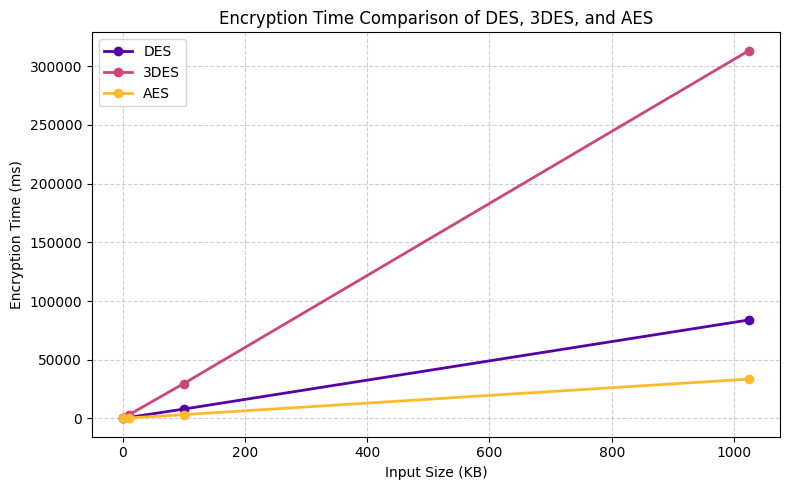

In [29]:
# Encryption Time Comparison
plt.figure(figsize=(8, 5))

for i in range(len(algorithms)):
    alg = algorithms[i]
    temp = df[df["Algorithm"] == alg]

    plt.plot(
        temp["Input Size KB"],
        temp["Encryption Time ms"],
        marker="o",
        linewidth=2,
        color=colors[i],
        label=alg
    )

plt.xlabel("Input Size (KB)")
plt.ylabel("Encryption Time (ms)")
plt.title("Encryption Time Comparison of DES, 3DES, and AES")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.savefig("figures/encryption_time_comparison.png", dpi=300)
plt.show()

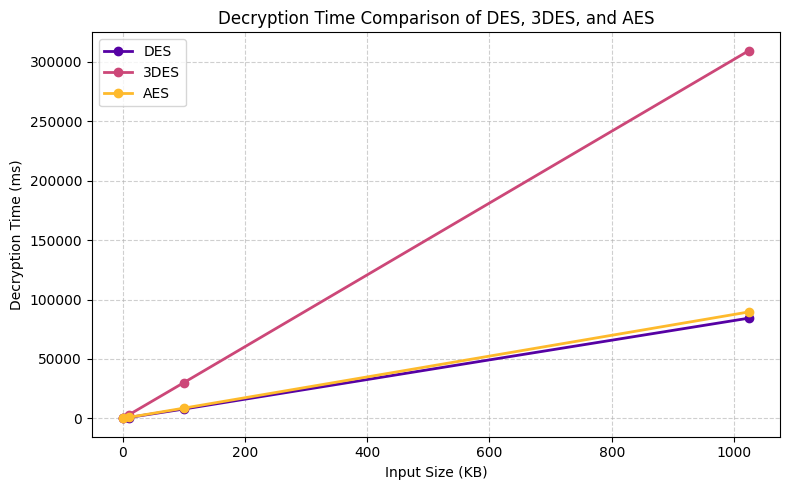

In [30]:
# Decryption Time Comparison
plt.figure(figsize=(8, 5))

for i in range(len(algorithms)):
    alg = algorithms[i]
    temp = df[df["Algorithm"] == alg]

    plt.plot(
        temp["Input Size KB"],
        temp["Decryption Time ms"],
        marker="o",
        linewidth=2,
        color=colors[i],
        label=alg
    )

plt.xlabel("Input Size (KB)")
plt.ylabel("Decryption Time (ms)")
plt.title("Decryption Time Comparison of DES, 3DES, and AES")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.savefig("figures/decryption_time_comparison.png", dpi=300)
plt.show()

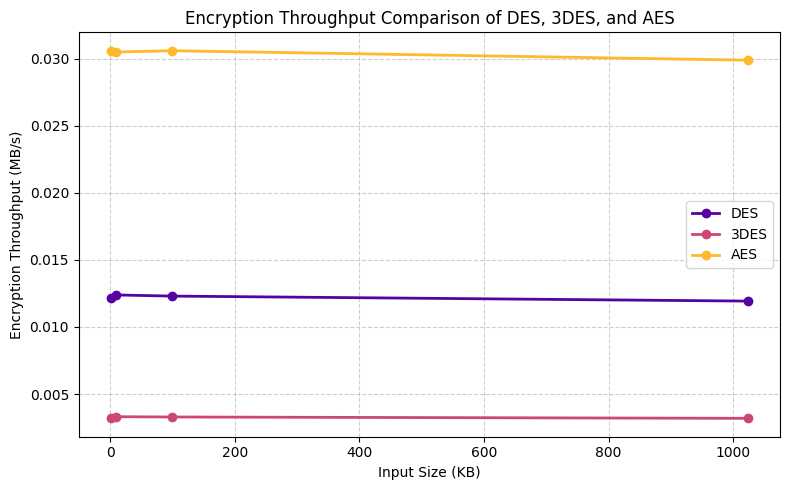

In [31]:
# Encryption Throughput Comparison
plt.figure(figsize=(8, 5))

for i in range(len(algorithms)):
    alg = algorithms[i]
    temp = df[df["Algorithm"] == alg]

    plt.plot(
        temp["Input Size KB"],
        temp["Encryption Throughput MB/s"],
        marker="o",
        linewidth=2,
        color=colors[i],
        label=alg
    )

plt.xlabel("Input Size (KB)")
plt.ylabel("Encryption Throughput (MB/s)")
plt.title("Encryption Throughput Comparison of DES, 3DES, and AES")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.savefig("figures/encryption_throughput_comparison.png", dpi=300)
plt.show()

In [32]:
df.to_csv("cipher_timing_results_with_throughput.csv", index=False)

print("\nPlots saved in the figures folder.")
print("Updated results saved to cipher_timing_results_with_throughput.csv")


Plots saved in the figures folder.
Updated results saved to cipher_timing_results_with_throughput.csv


## Internal Component Timing for DES and AES (optional)

In [33]:
# DES Profiling Functions
def timed_permute(k, arr, n, des_profile):
    start_time = time.perf_counter()

    permutation = ""
    for i in range(0, n):
        permutation = permutation + k[arr[i] - 1]

    end_time = time.perf_counter()
    des_profile["permutation_time"] = des_profile["permutation_time"] + (end_time - start_time)

    return permutation


def generate_des_round_keys_timed(key_hex):
    start_time = time.perf_counter()

    round_keys_bin, round_keys_hex = generate_des_round_keys(key_hex)

    end_time = time.perf_counter()
    key_generation_time = end_time - start_time

    return round_keys_bin, round_keys_hex, key_generation_time


def des_encrypt_block_profile(block_hex, round_keys_bin, des_profile):
    start_block_time = time.perf_counter()

    block_bin = hex2bin(block_hex)

    # Initial permutation
    block_bin = timed_permute(block_bin, initial_perm, 64, des_profile)

    left = block_bin[0:32]
    right = block_bin[32:64]

    for i in range(0, 16):

        # Expansion permutation
        right_expanded = timed_permute(right, exp_d, 48, des_profile)

        # XOR with round key
        xor_x = xor(right_expanded, round_keys_bin[i])

        # S-box operation
        start_sbox_time = time.perf_counter()

        sbox_str = ""

        for j in range(0, 8):
            row = bin2dec(xor_x[j * 6] + xor_x[j * 6 + 5])
            col = bin2dec(xor_x[j * 6 + 1] + xor_x[j * 6 + 2] +
                          xor_x[j * 6 + 3] + xor_x[j * 6 + 4])

            val = sbox[j][row][col]
            sbox_str = sbox_str + dec2bin(val)

        end_sbox_time = time.perf_counter()
        des_profile["sbox_time"] = des_profile["sbox_time"] + (end_sbox_time - start_sbox_time)

        # Straight permutation after S-box
        sbox_str = timed_permute(sbox_str, per, 32, des_profile)

        # XOR with left half
        result = xor(left, sbox_str)
        left = result

        # Swapping
        if i != 15:
            left, right = right, left

    combine = left + right

    # Final permutation
    cipher_text = timed_permute(combine, final_perm, 64, des_profile)

    end_block_time = time.perf_counter()
    des_profile["block_encryption_time"] = des_profile["block_encryption_time"] + (end_block_time - start_block_time)

    return bin2hex(cipher_text)


def des_encrypt_profile(data, key):
    data = pad_data(data, 8)

    des_profile = {
        "key_generation_time": 0.0,
        "block_encryption_time": 0.0,
        "sbox_time": 0.0,
        "permutation_time": 0.0,
        "number_of_blocks": 0
    }

    key_hex = bytes_to_hex(key)

    round_keys_bin, round_keys_hex, key_generation_time = generate_des_round_keys_timed(key_hex)

    des_profile["key_generation_time"] = key_generation_time

    result = b""

    for i in range(0, len(data), 8):
        block = data[i:i + 8]
        block_hex = bytes_to_hex(block)

        cipher_hex = des_encrypt_block_profile(block_hex, round_keys_bin, des_profile)

        result = result + hex_to_bytes(cipher_hex)
        des_profile["number_of_blocks"] = des_profile["number_of_blocks"] + 1

    return result, des_profile

In [34]:
# AES Profiling Functions
def aes_key_expansion_timed(key):
    start_time = time.perf_counter()

    round_keys = aes_key_expansion(key)

    end_time = time.perf_counter()
    key_expansion_time = end_time - start_time

    return round_keys, key_expansion_time


def add_round_key_timed(state, round_key, aes_profile):
    start_time = time.perf_counter()

    add_round_key(state, round_key)

    end_time = time.perf_counter()
    aes_profile["add_round_key_time"] = aes_profile["add_round_key_time"] + (end_time - start_time)


def sub_bytes_timed(state, aes_profile):
    start_time = time.perf_counter()

    sub_bytes(state)

    end_time = time.perf_counter()
    aes_profile["subbytes_time"] = aes_profile["subbytes_time"] + (end_time - start_time)


def shift_rows_timed(state, aes_profile):
    start_time = time.perf_counter()

    shift_rows(state)

    end_time = time.perf_counter()
    aes_profile["shiftrows_time"] = aes_profile["shiftrows_time"] + (end_time - start_time)


def mix_columns_timed(state, aes_profile):
    start_time = time.perf_counter()

    mix_columns(state)

    end_time = time.perf_counter()
    aes_profile["mixcolumns_time"] = aes_profile["mixcolumns_time"] + (end_time - start_time)


def aes_encrypt_block_profile(block, round_keys, aes_profile):
    state = bytes2matrix(block)

    # Initial AddRoundKey
    add_round_key_timed(state, round_keys[0], aes_profile)

    # Rounds 1 to 9
    for round_num in range(1, 10):
        sub_bytes_timed(state, aes_profile)
        shift_rows_timed(state, aes_profile)
        mix_columns_timed(state, aes_profile)
        add_round_key_timed(state, round_keys[round_num], aes_profile)

    # Final round does not have MixColumns
    sub_bytes_timed(state, aes_profile)
    shift_rows_timed(state, aes_profile)
    add_round_key_timed(state, round_keys[10], aes_profile)

    cipher_block = matrix2bytes(state)

    return cipher_block


def aes_encrypt_profile(data, key):
    data = pad_data(data, 16)

    aes_profile = {
        "key_expansion_time": 0.0,
        "subbytes_time": 0.0,
        "shiftrows_time": 0.0,
        "mixcolumns_time": 0.0,
        "add_round_key_time": 0.0,
        "block_encryption_time": 0.0,
        "number_of_blocks": 0
    }

    round_keys, key_expansion_time = aes_key_expansion_timed(key)
    aes_profile["key_expansion_time"] = key_expansion_time

    result = b""

    start_block_time = time.perf_counter()

    for i in range(0, len(data), 16):
        block = data[i:i + 16]

        cipher_block = aes_encrypt_block_profile(block, round_keys, aes_profile)

        result = result + cipher_block
        aes_profile["number_of_blocks"] = aes_profile["number_of_blocks"] + 1

    end_block_time = time.perf_counter()
    aes_profile["block_encryption_time"] = end_block_time - start_block_time

    return result, aes_profile

In [35]:
def run_internal_component_timing():
    des_key = b"12345678"
    aes_key = b"1234567890ABCDEF"

    input_sizes = [
        1024,          # 1 KB
        10 * 1024,     # 10 KB
        100 * 1024,    # 100 KB
        1024 * 1024    # 1 MB
    ]

    des_results = []
    aes_results = []

    for size in input_sizes:
        print("\n============================================")
        print("Internal component timing for input size:", size, "bytes")
        print("============================================")

        data = os.urandom(size)

        # -------------------------------
        # DES profiling
        # -------------------------------

        cipher_des, des_profile = des_encrypt_profile(data, des_key)

        des_blocks = des_profile["number_of_blocks"]

        print("\nDES Component Timing")
        print("Number of DES blocks:", des_blocks)
        print("Key generation time:", des_profile["key_generation_time"])
        print("Block encryption time:", des_profile["block_encryption_time"])
        print("S-box operation time:", des_profile["sbox_time"])
        print("Permutation time:", des_profile["permutation_time"])
        print("Average block encryption time:", des_profile["block_encryption_time"] / des_blocks)

        des_results.append([
            size,
            des_blocks,
            des_profile["key_generation_time"],
            des_profile["block_encryption_time"],
            des_profile["sbox_time"],
            des_profile["permutation_time"],
            des_profile["block_encryption_time"] / des_blocks
        ])

        # -------------------------------
        # AES profiling
        # -------------------------------

        cipher_aes, aes_profile = aes_encrypt_profile(data, aes_key)

        aes_blocks = aes_profile["number_of_blocks"]

        print("\nAES Component Timing")
        print("Number of AES blocks:", aes_blocks)
        print("Key expansion time:", aes_profile["key_expansion_time"])
        print("Block encryption time:", aes_profile["block_encryption_time"])
        print("SubBytes time:", aes_profile["subbytes_time"])
        print("ShiftRows time:", aes_profile["shiftrows_time"])
        print("MixColumns time:", aes_profile["mixcolumns_time"])
        print("AddRoundKey time:", aes_profile["add_round_key_time"])
        print("Average block encryption time:", aes_profile["block_encryption_time"] / aes_blocks)

        aes_results.append([
            size,
            aes_blocks,
            aes_profile["key_expansion_time"],
            aes_profile["block_encryption_time"],
            aes_profile["subbytes_time"],
            aes_profile["shiftrows_time"],
            aes_profile["mixcolumns_time"],
            aes_profile["add_round_key_time"],
            aes_profile["block_encryption_time"] / aes_blocks
        ])

    # Save DES component timing results
    with open("des_component_timing_results.csv", "w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow([
            "Input Size Bytes",
            "Number of Blocks",
            "Key Generation Time Seconds",
            "Block Encryption Time Seconds",
            "S-box Operation Time Seconds",
            "Permutation Time Seconds",
            "Average Block Encryption Time Seconds"
        ])
        writer.writerows(des_results)

    # Save AES component timing results
    with open("aes_component_timing_results.csv", "w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow([
            "Input Size Bytes",
            "Number of Blocks",
            "Key Expansion Time Seconds",
            "Block Encryption Time Seconds",
            "SubBytes Time Seconds",
            "ShiftRows Time Seconds",
            "MixColumns Time Seconds",
            "AddRoundKey Time Seconds",
            "Average Block Encryption Time Seconds"
        ])
        writer.writerows(aes_results)

    print("\nDES component timing saved to des_component_timing_results.csv")
    print("AES component timing saved to aes_component_timing_results.csv")

    return des_results, aes_results

In [36]:
# Plot Internal Component Timing
def plot_des_component_timing(des_results):
    input_sizes_kb = []
    key_generation = []
    block_encryption = []
    sbox_time = []
    permutation_time = []

    for row in des_results:
        input_sizes_kb.append(row[0] / 1024)
        key_generation.append(row[2])
        block_encryption.append(row[3])
        sbox_time.append(row[4])
        permutation_time.append(row[5])

    colors = plt.cm.plasma(np.linspace(0.15, 0.85, 4))

    plt.figure(figsize=(8, 5))

    plt.plot(input_sizes_kb, key_generation, marker="o", linewidth=2,
             color=colors[0], label="Key Generation")
    plt.plot(input_sizes_kb, block_encryption, marker="o", linewidth=2,
             color=colors[1], label="Block Encryption")
    plt.plot(input_sizes_kb, sbox_time, marker="o", linewidth=2,
             color=colors[2], label="S-box")
    plt.plot(input_sizes_kb, permutation_time, marker="o", linewidth=2,
             color=colors[3], label="Permutation")

    plt.xlabel("Input Size (KB)")
    plt.ylabel("Time (seconds)")
    plt.title("DES Internal Component Timing")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()

    plt.savefig("des_internal_component_timing.png", dpi=300)
    plt.show()


def plot_aes_component_timing(aes_results):
    input_sizes_kb = []
    key_expansion = []
    subbytes_time = []
    shiftrows_time = []
    mixcolumns_time = []
    add_round_key_time = []

    for row in aes_results:
        input_sizes_kb.append(row[0] / 1024)
        key_expansion.append(row[2])
        subbytes_time.append(row[4])
        shiftrows_time.append(row[5])
        mixcolumns_time.append(row[6])
        add_round_key_time.append(row[7])

    colors = plt.cm.plasma(np.linspace(0.10, 0.90, 5))

    plt.figure(figsize=(8, 5))

    plt.plot(input_sizes_kb, key_expansion, marker="o", linewidth=2,
             color=colors[0], label="Key Expansion")
    plt.plot(input_sizes_kb, subbytes_time, marker="o", linewidth=2,
             color=colors[1], label="SubBytes")
    plt.plot(input_sizes_kb, shiftrows_time, marker="o", linewidth=2,
             color=colors[2], label="ShiftRows")
    plt.plot(input_sizes_kb, mixcolumns_time, marker="o", linewidth=2,
             color=colors[3], label="MixColumns")
    plt.plot(input_sizes_kb, add_round_key_time, marker="o", linewidth=2,
             color=colors[4], label="AddRoundKey")

    plt.xlabel("Input Size (KB)")
    plt.ylabel("Time (seconds)")
    plt.title("AES Internal Component Timing")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()

    plt.savefig("aes_internal_component_timing.png", dpi=300)
    plt.show()


Internal component timing for input size: 1024 bytes

DES Component Timing
Number of DES blocks: 129
Key generation time: 0.00016879999998309358
Block encryption time: 0.08791439999936301
S-box operation time: 0.044844100003274434
Permutation time: 0.021558400002277267
Average block encryption time: 0.0006815069767392482

AES Component Timing
Number of AES blocks: 65
Key expansion time: 0.00010629999997036066
Block encryption time: 0.02694259999998394
SubBytes time: 0.0016112000006387461
ShiftRows time: 0.0007252000012840654
MixColumns time: 0.021257599999898957
AddRoundKey time: 0.002293099999064907
Average block encryption time: 0.0004145015384612914

Internal component timing for input size: 10240 bytes

DES Component Timing
Number of DES blocks: 1281
Key generation time: 0.00015880000000834116
Block encryption time: 0.8105197999990423
S-box operation time: 0.4125692999896273
Permutation time: 0.19938250001746383
Average block encryption time: 0.0006327242779071368

AES Component T

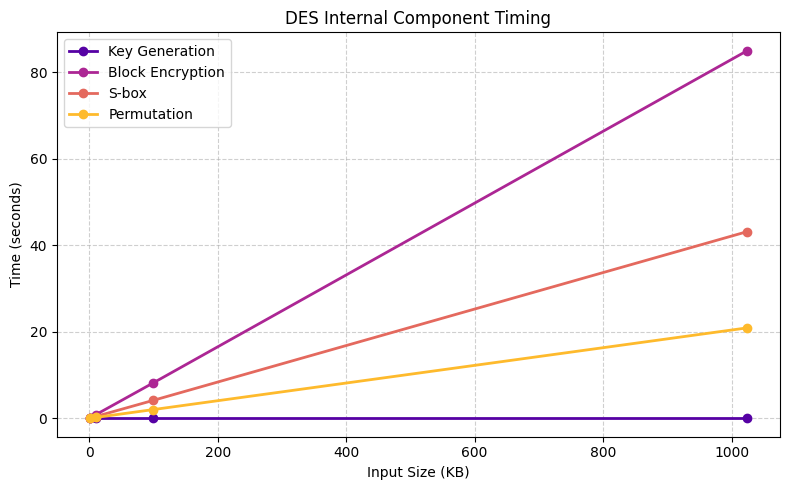

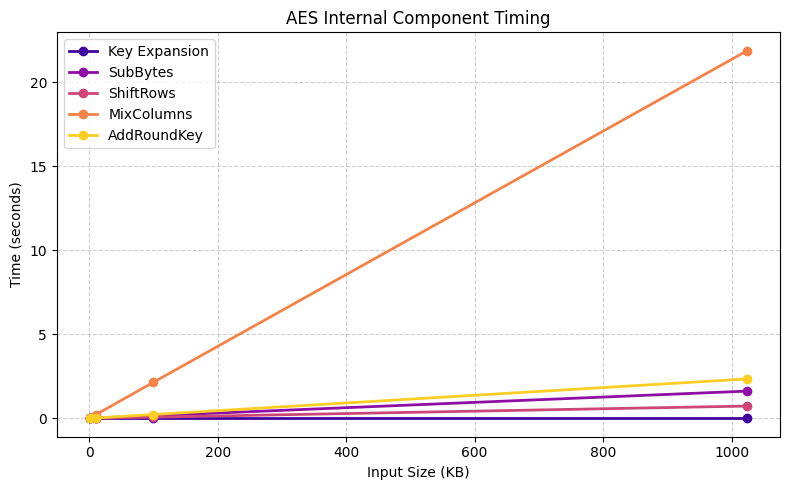

In [37]:
if __name__ == "__main__":
    des_results, aes_results = run_internal_component_timing()

    plot_des_component_timing(des_results)
    plot_aes_component_timing(aes_results)